# EvidenceIQ: Exploring the Data

Dataset: Online Retail II, a UK online gift shop, December 2009 to December 2011.

Before we build an AI analyst we need to know what is actually in the data.
If we don't know where the traps are, we won't notice when the AI falls into one.

Questions we want to answer:

1. What does the data look like?
2. Are there duplicates?
3. How does revenue change over time?
4. Which countries and products matter?
5. Who are the customers?
6. What is happening with returns?

## Step 1: Load the data

The file has two sheets, one for each year, so we read both and join them together.
This takes about 45 seconds.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = "../data/raw/online_retail_II.xlsx"

sheet1 = pd.read_excel(RAW, sheet_name="Year 2009-2010")
sheet2 = pd.read_excel(RAW, sheet_name="Year 2010-2011")

print("Sheet 1:", sheet1.shape)
print("Sheet 2:", sheet2.shape)

Sheet 1: (525461, 8)
Sheet 2: (541910, 8)


In [2]:
df = pd.concat([sheet1, sheet2], ignore_index=True)
print("Together:", df.shape)

Together: (1067371, 8)


## Step 2: First look

Always look at the real rows before doing anything else.

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [5]:
# How many values are missing?
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

So far we can see:

- One row is one product line on one receipt, not one whole order.
- Customer ID is missing a lot. We will measure that properly later.
- Quantity can be negative. Those rows are returns and cancellations.

In [6]:
print("First date:", df["InvoiceDate"].min())
print("Last date: ", df["InvoiceDate"].max())

First date: 2009-12-01 07:45:00
Last date:  2011-12-09 12:50:00


## Step 3: Checking for duplicates

This turned out to be the most important step in the whole notebook.

The two sheets are supposed to cover different years. Let's check that they really do.

In [7]:
print("Sheet 1 ends:  ", sheet1["InvoiceDate"].max())
print("Sheet 2 starts:", sheet2["InvoiceDate"].min())

Sheet 1 ends:   2010-12-09 20:01:00
Sheet 2 starts: 2010-12-01 08:26:00


They overlap. Sheet 1 runs until 9 December 2010, but sheet 2 starts on 1 December 2010.
So the first nine days of December 2010 are in the file twice.

Let's see how many invoices appear in both sheets.

In [8]:
invoices1 = set(sheet1["Invoice"])
invoices2 = set(sheet2["Invoice"])

print("Invoices in both sheets:", len(invoices1 & invoices2))

Invoices in both sheets: 1088


Why this matters: if we don't fix it, December 2010 revenue looks like 1,126,445
when the real number is 746,724. That is 51 percent too high, and it would spoil
every year on year comparison we make later.

We checked those 1,088 invoices and they are identical in both sheets, so the
second copy tells us nothing new and it is safe to remove.

In [9]:
rows_before = len(df)
df = df.drop_duplicates()

print("Rows before:", rows_before)
print("Rows after: ", len(df))
print("Removed:    ", rows_before - len(df))

Rows before: 1067371
Rows after:  1033036
Removed:     34335


## Step 4: Cleaning

Four small decisions. We write them down because the AI has to follow exactly the
same rules, otherwise its answers won't match ours.

Decision 1: remove the bad debt adjustments. A few invoices start with the letter A.
They are accounting entries, not sales, and one of them is minus 53,594, which would
ruin whichever month it landed in.

In [10]:
df["Invoice"] = df["Invoice"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)

# look at them before we delete them
df[df["Invoice"].str.startswith("A")][["Invoice", "Description", "Quantity", "Price"]]

,Invoice,Description,Quantity,Price
179403,A506401,Adjust bad debt,1,-53594.36
276274,A516228,Adjust bad debt,1,-44031.79
403472,A528059,Adjust bad debt,1,-38925.87
825443,A563185,Adjust bad debt,1,11062.06
825444,A563186,Adjust bad debt,1,-11062.06
825445,A563187,Adjust bad debt,1,-11062.06


In [11]:
df = df[~df["Invoice"].str.startswith("A")]
print("Rows now:", len(df))

Rows now: 1033030


Decision 2: revenue is quantity times price. There is no revenue column so we make one.

Decision 3: invoices starting with C are cancellations. We keep them, because net
revenue should include them, but we flag them so we can separate sales from returns.

Decision 4: add a month column, a date column and a year column so grouping is easy later.

In [12]:
df["Revenue"] = df["Quantity"] * df["Price"]
df["IsCancelled"] = df["Invoice"].str.startswith("C")
df["Month"] = df["InvoiceDate"].dt.strftime("%Y-%m")
df["Date"] = df["InvoiceDate"].dt.date
df["Year"] = df["InvoiceDate"].dt.year

print("Rows:", len(df))
print("Total revenue:", round(df["Revenue"].sum(), 2))

Rows: 1033030
Total revenue: 19003147.78


Our baseline is 1,033,030 rows and 19,003,147.78 in revenue.

If your notebook shows something different then the cleaning steps have changed,
so check before carrying on.

## Step 5: Revenue over time

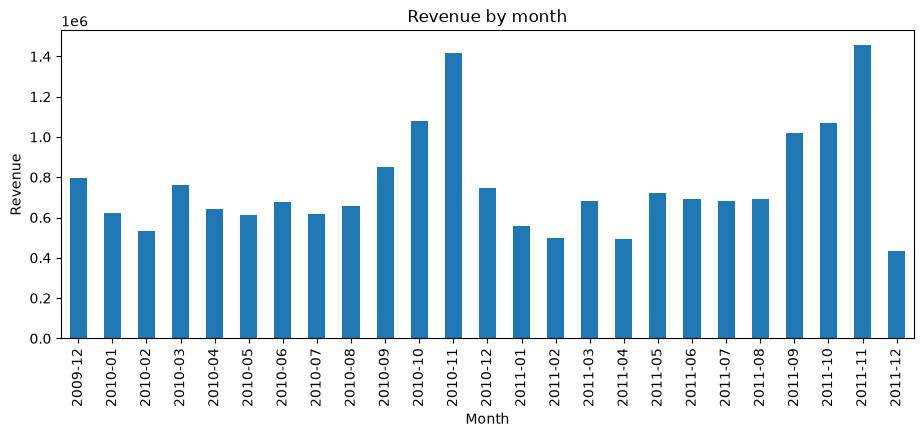

In [13]:
monthly = df.groupby("Month")["Revenue"].sum()

monthly.plot(kind="bar", figsize=(11, 4))
plt.title("Revenue by month")
plt.ylabel("Revenue")
plt.show()

In [14]:
monthly.round(0)

Month
2009-12     796648.0
2010-01     622480.0
2010-02     531265.0
2010-03     763247.0
2010-04     641521.0
2010-05     613271.0
2010-06     677074.0
2010-07     617365.0
2010-08     654774.0
2010-09     851106.0
2010-10    1080611.0
2010-11    1416697.0
2010-12     746724.0
2011-01     558449.0
2011-02     497026.0
2011-03     682014.0
2011-04     492368.0
2011-05     722094.0
2011-06     689977.0
2011-07     680157.0
2011-08     692449.0
2011-09    1017597.0
2011-10    1069368.0
2011-11    1456146.0
2011-12     432719.0
Name: Revenue, dtype: float64

The last bar is misleading. December 2011 looks like a crash, but the data just
stops on the 9th. It is a partial month, not a bad month.

We can show this by counting how many days the shop actually traded each month.

In [15]:
trading_days = df.groupby("Month")["Date"].nunique()

summary = pd.DataFrame({"Revenue": monthly.round(0), "TradingDays": trading_days})
summary.tail(4)

,Revenue,TradingDays
Month,,
2011-09,1017597.0,26
2011-10,1069368.0,26
2011-11,1456146.0,26
2011-12,432719.0,8


December 2011 has only 8 trading days, compared with about 26 in a normal month.

Rule for EvidenceIQ: never treat December 2011 as a complete month. The AI must
refuse the comparison or clearly warn about it.

### Different months have different numbers of trading days

Even complete months are not fair comparisons. March and April 2011 show this best.

In [16]:
march = df[df["Month"] == "2011-03"]
april = df[df["Month"] == "2011-04"]

march_days = march["Date"].nunique()
april_days = april["Date"].nunique()

print("March:", round(march["Revenue"].sum()), "over", march_days, "days")
print("April:", round(april["Revenue"].sum()), "over", april_days, "days")

March: 682014 over 27 days
April: 492368 over 21 days


## Step 6: Countries

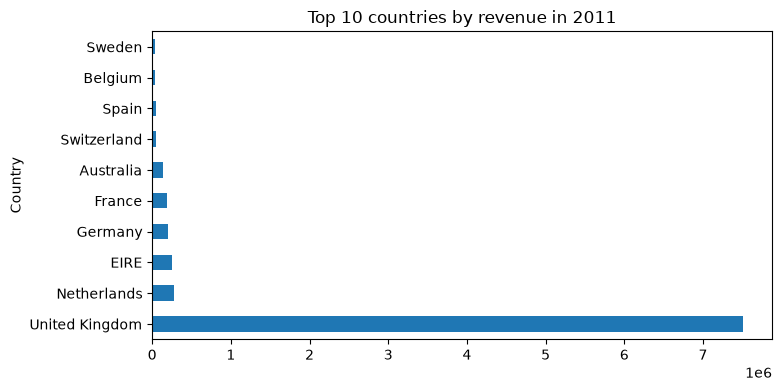

In [18]:
df_2011 = df[df["Year"] == 2011]
by_country = df_2011.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

by_country.head(10).plot(kind="barh", figsize=(8, 4))
plt.title("Top 10 countries by revenue in 2011")
plt.show()

In [19]:
uk_share = 100 * by_country["United Kingdom"] / by_country.sum()
print("UK share of 2011 revenue:", round(uk_share, 1), "%")

UK share of 2011 revenue: 83.5 %


The UK is 83.5 percent of revenue, so the chart is basically one bar.

What this means for our benchmark: asking which country made the most money is a
useless question, because the answer is always the UK. Country questions need to
exclude the UK if they are going to test anything.

In [20]:
orders = df_2011.groupby("Country")["Invoice"].nunique()
customers = df_2011.groupby("Country")["Customer ID"].nunique()

table = pd.DataFrame({
    "Revenue": by_country.round(0),
    "Orders": orders,
    "Customers": customers,
})
table["AvgOrder"] = (table["Revenue"] / table["Orders"]).round(0)

table.sort_values("Revenue", ascending=False).head(8)

,Revenue,Orders,Customers,AvgOrder
Country,,,,
United Kingdom,7503574.0,21606,3835,347.0
Netherlands,275877.0,98,8,2815.0
EIRE,253963.0,338,3,751.0
Germany,206982.0,560,93,370.0
France,187760.0,437,84,430.0
Australia,136072.0,65,9,2093.0
Switzerland,55058.0,72,21,765.0
Spain,52912.0,101,30,524.0


Be careful with average order value. The Netherlands looks amazing, around 2,800
per order against 347 for the UK, but that is only 8 customers. Australia is 9.

These are not really markets, they are a few big wholesale accounts. Any ranking
by average order value needs a minimum number of orders or it is just noise.

## Step 7: Products

In [21]:
sales = df[df["Quantity"] > 0]        # ignore returns for this part
by_product = sales.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False)

by_product.head(10).round(0)

StockCode
M         339600.0
22423     330590.0
DOT       309854.0
85123A    257725.0
85099B    180569.0
23843     168470.0
47566     148318.0
84879     129324.0
POST      125682.0
22086     117760.0
Name: Revenue, dtype: float64

In [22]:
# How much of the revenue comes from the best products?
share = by_product.cumsum() / by_product.sum()
n80 = (share <= 0.8).sum() + 1

print("Total products:", len(by_product))
print("Products making 80% of revenue:", n80)
print("That is", round(100 * n80 / len(by_product)), "% of the catalogue")

Total products: 4984
Products making 80% of revenue: 1009
That is 20 % of the catalogue


About a fifth of the products earn about four fifths of the money, which is the usual 80/20 pattern.

## Step 8: When do people buy?

This tells us what kind of business we are looking at.

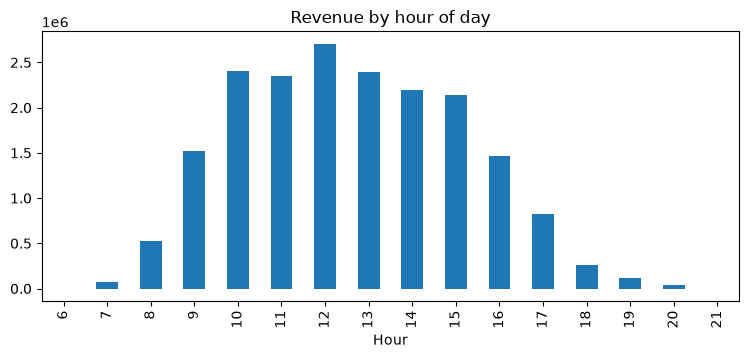

In [23]:
by_hour = df.groupby(df["InvoiceDate"].dt.hour)["Revenue"].sum()

by_hour.plot(kind="bar", figsize=(9, 3.5))
plt.title("Revenue by hour of day")
plt.xlabel("Hour")
plt.show()

In [24]:
df.groupby(df["InvoiceDate"].dt.day_name())["Revenue"].sum().sort_values(ascending=False).round(0)

InvoiceDate
Thursday     3940111.0
Tuesday      3724296.0
Wednesday    3317371.0
Monday       3317210.0
Friday       2915323.0
Sunday       1779033.0
Saturday        9803.0
Name: Revenue, dtype: float64

In [25]:
saturday = df[df["InvoiceDate"].dt.day_name() == "Saturday"]
print("Saturday dates in the whole dataset:", saturday["Date"].unique())

Saturday dates in the whole dataset: [datetime.date(2009, 12, 5)]


This is a wholesale business, not a normal shop.

- Buying happens between 9am and 4pm on weekdays, which is office hours.
- There is only one Saturday in the entire dataset, 5 December 2009.
- So saying Saturday is our worst day would be nonsense built on one single day.

We should describe our users as wholesale buyers, not shoppers.

In [26]:
order_totals = df[df["IsCancelled"] == False].groupby("Invoice")["Revenue"].sum()
order_totals.describe().round(0)

count     45330.0
mean        451.0
std        1402.0
min           0.0
25%         103.0
50%         258.0
75%         449.0
max      168470.0
Name: Revenue, dtype: float64

The middle order is about 258 but the average is about 451, because a few very large
orders pull the average up.

We should use the median when describing a typical order, and so should the AI.

## Step 9: Customers

In [27]:
known = sales[sales["Customer ID"].notnull()]
by_customer = known.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False)

print("Number of customers:", len(by_customer))
print("Top 10 customers make", round(100 * by_customer.head(10).sum() / by_customer.sum(), 1), "% of revenue")

Number of customers: 5881
Top 10 customers make 16.0 % of revenue


In [28]:
orders_each = known.groupby("Customer ID")["Invoice"].nunique()

print("Median orders per customer:", orders_each.median())
print("Customers who ordered only once:", (orders_each == 1).sum())
print("That is", round(100 * (orders_each == 1).mean()), "% of customers")

Median orders per customer: 3.0
Customers who ordered only once: 1626
That is 28 % of customers


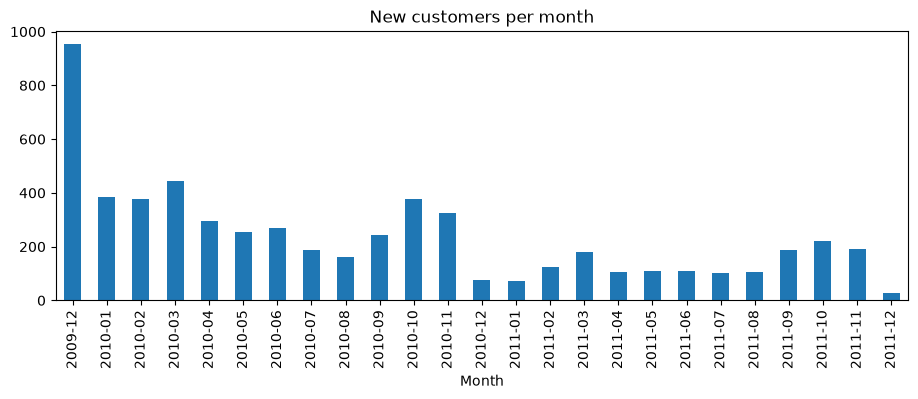

In [29]:
# What month did each customer first buy something?
first_month = known.groupby("Customer ID")["Month"].min()

first_month.value_counts().sort_index().plot(kind="bar", figsize=(11, 3.5))
plt.title("New customers per month")
plt.show()

There is a real business story here. The shop got 955 new customers in December 2009,
then only about 100 to 200 a month through 2011. Revenue stayed flat because the
existing customers kept spending, not because new ones arrived.

That would make a good hard question for our benchmark.

## Step 10: Returns

Negative quantities are returns and cancellations. Let's see how big they are.

In [30]:
returns = df[df["Quantity"] < 0]
print("Total value of returns:", round(-returns["Revenue"].sum()))

Total value of returns: 1462424


In [31]:
# Which product codes are returned the most in 2011?
returns_2011 = df[(df["Quantity"] < 0) & (df["Year"] == 2011)]
by_returned = returns_2011.groupby("StockCode")["Revenue"].sum().sort_values()

names = df.groupby("StockCode")["Description"].first()

for code in by_returned.head(5).index:
    print(code, round(-by_returned[code]), names[code])

AMAZONFEE 182497 AMAZON FEE
23843 168470 PAPER CRAFT , LITTLE BIRDIE
M 144253 Manual
23166 77480 MEDIUM CERAMIC TOP STORAGE JAR
POST 11827 POSTAGE


In [32]:
total_returns = -returns_2011["Revenue"].sum()
print("Those 5 codes are", round(100 * -by_returned.head(5).sum() / total_returns), "% of all 2011 returns")

Those 5 codes are 71 % of all 2011 returns


Most of the returns are not really returns.

AMAZONFEE and Manual are not products at all. Two of the others are single strange
orders. Let's look at those.

In [33]:
big = df[(df["Quantity"] > 50000) | (df["Quantity"] < -50000)]
big[["Invoice", "StockCode", "Quantity", "InvoiceDate", "Price", "Customer ID"]]

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID
587080,541431,23166,74215,2011-01-18 10:01:00,1.04,12346.0
587085,C541433,23166,-74215,2011-01-18 10:17:00,1.04,12346.0
1065882,581483,23843,80995,2011-12-09 09:15:00,2.08,16446.0
1065883,C581484,23843,-80995,2011-12-09 09:27:00,2.08,16446.0


Someone ordered 80,995 paper craft items and cancelled 12 minutes later. The same
thing happened with 74,215 storage jars in January.

These two orders on their own are a big share of all returns. If we leave everything
in, the return rate is about 8 percent. If we take out the non products and these two
strange orders, the real product return rate is about 2.4 percent.

Both numbers can be defended, which is exactly why we have to write the definition down.

## Step 11: Two last things to watch out for

In [34]:
no_id = df["Customer ID"].isnull()

print("Rows with no Customer ID:   ", round(100 * no_id.mean(), 1), "%")
print("Revenue with no Customer ID:", round(100 * df[no_id]["Revenue"].sum() / df["Revenue"].sum(), 1), "%")

Rows with no Customer ID:    22.8 %
Revenue with no Customer ID: 14.3 %


Nearly a quarter of rows have no customer. That is fine for revenue questions, but
any question about customers quietly ignores those rows, so the AI has to say so.

In [35]:
# The same product code does not always have the same description
df[df["StockCode"] == "22502"]["Description"].value_counts().head()

Description
PICNIC BASKET WICKER SMALL           950
PICNIC BASKET WICKER 60 PIECES         2
mailout                                1
Donated to The Food Chain charity      1
reverse 21/5/10 adjustment             1
Name: count, dtype: int64

If we take the first description we might end up calling this product
"reverse 21/5/10 adjustment". We should take the most common one instead.

## What we found

1. The two sheets overlap by nine days, so December 2010 is 51 percent too high if
   we don't remove duplicates.
2. December 2011 stops on the 9th, so it is never a complete month.
3. Months have different numbers of trading days, so we must say the day count.
4. The UK is 83.5 percent of revenue, so country questions must exclude it.
5. Small countries have very few customers, so we need a minimum order count
   before ranking them.
6. About 20 percent of products make 80 percent of the revenue.
7. Order values are very skewed, so we should report the median.
8. It is a wholesale business with office hours and no Saturdays.
9. Returns are dominated by fees and two strange orders.
10. 22.8 percent of rows have no Customer ID.
11. Product descriptions are inconsistent for the same code.